# Lab 4 – LSTM-Based Traffic Volume Forecasting

This notebook implements an LSTM neural network for hourly traffic-volume forecasting using the Metro Interstate Traffic Volume dataset.

The workflow includes data cleaning, exploratory data visualization, chronological train-test splitting, Min-Max normalization, 24-hour sequence creation, LSTM training, early stopping, prediction, evaluation using MAE/RMSE/MAPE, and next-hour forecasting.

In [24]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Libraries imported successfully.")

Libraries imported successfully.


In [26]:
# Load dataset
DATASET_PATH = "Metro_Interstate_Traffic_Volume.csv"

df = pd.read_csv(DATASET_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [29]:
# Basic dataset inspection
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Columns:
['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume']

Missing values:
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

Duplicate rows: 17

Data types:
holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object


In [30]:
# Data cleaning and chronological sorting
df["date_time"] = pd.to_datetime(df["date_time"])
df = df.sort_values("date_time")
df = df.drop_duplicates(subset=["date_time"])
df = df.dropna(subset=["traffic_volume"])

print("Cleaned dataset shape:", df.shape)
print("Date range:", df["date_time"].min(), "to", df["date_time"].max())

Cleaned dataset shape: (40575, 9)
Date range: 2012-10-02 09:00:00 to 2018-09-30 23:00:00


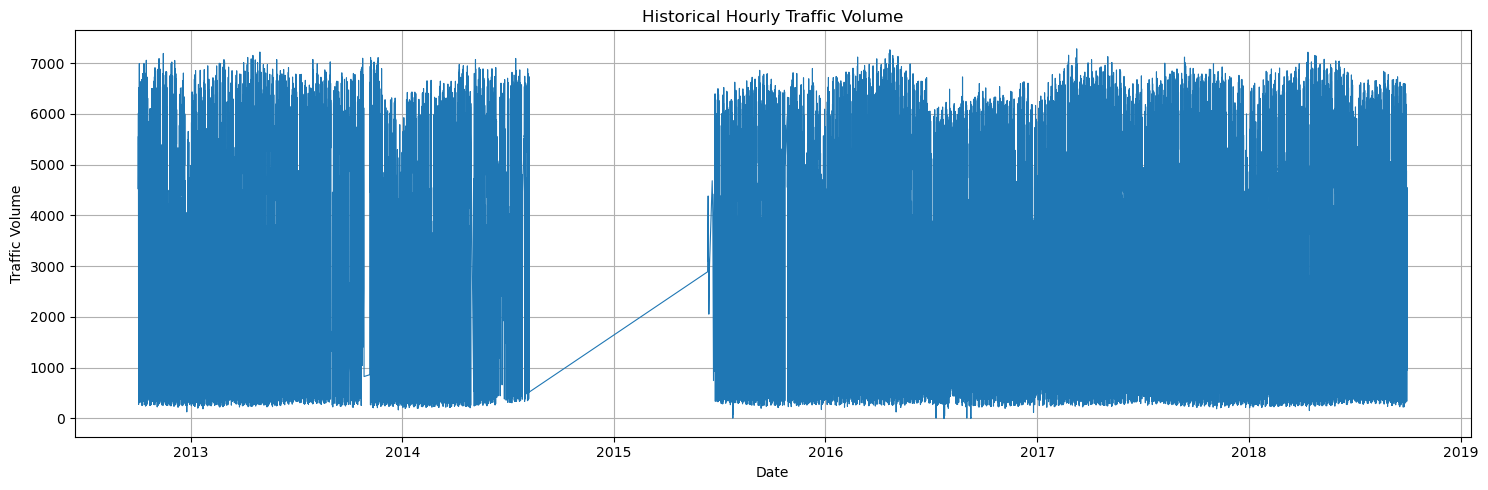

In [31]:
# Visualization 1: Historical traffic volume
plt.figure(figsize=(15, 5))
plt.plot(df["date_time"], df["traffic_volume"], linewidth=0.8)
plt.title("Historical Hourly Traffic Volume")
plt.xlabel("Date")
plt.ylabel("Traffic Volume")
plt.grid(True)
plt.tight_layout()
plt.show()

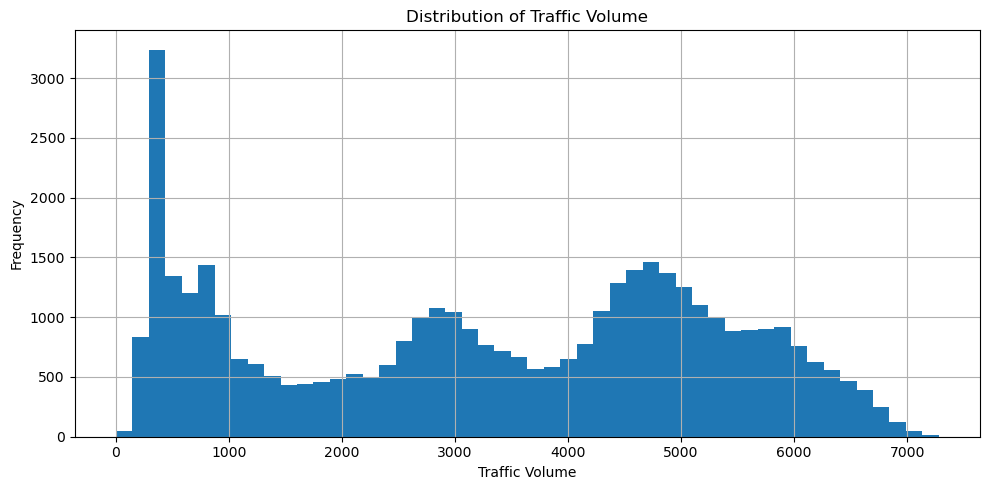

In [32]:
# Visualization 2: Traffic-volume distribution
plt.figure(figsize=(10, 5))
plt.hist(df["traffic_volume"], bins=50)
plt.title("Distribution of Traffic Volume")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

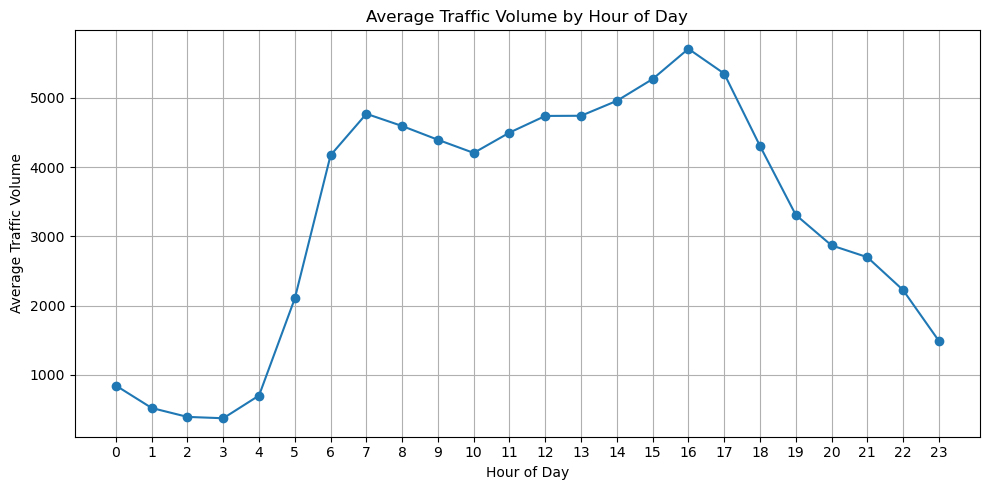

In [33]:
# Visualization 3: Average traffic by hour of day
df["hour"] = df["date_time"].dt.hour
hourly_average = df.groupby("hour")["traffic_volume"].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_average.index, hourly_average.values, marker="o")
plt.title("Average Traffic Volume by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Volume")
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()

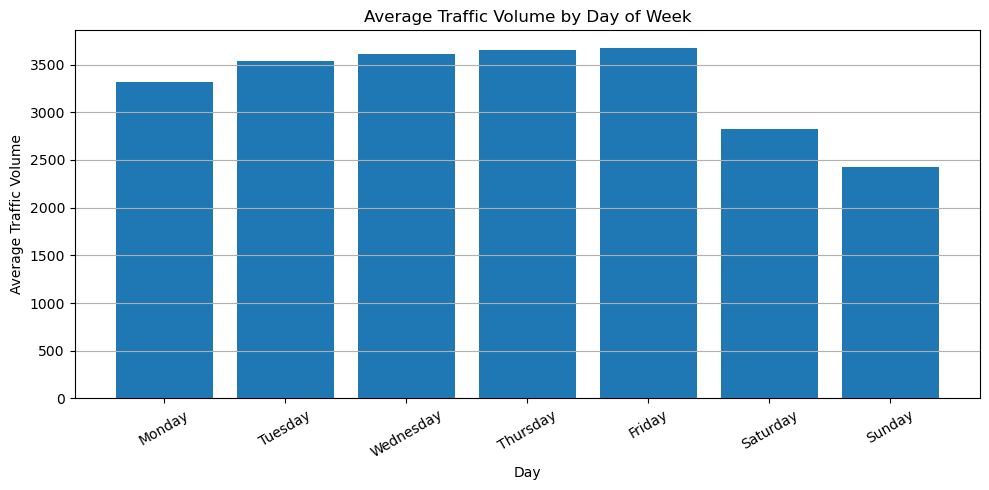

In [34]:
# Visualization 4: Average traffic by day of week
df["day_of_week"] = df["date_time"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

daily_average = df.groupby("day_of_week")["traffic_volume"].mean().reindex(day_order)

plt.figure(figsize=(10, 5))
plt.bar(daily_average.index, daily_average.values)
plt.title("Average Traffic Volume by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Traffic Volume")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

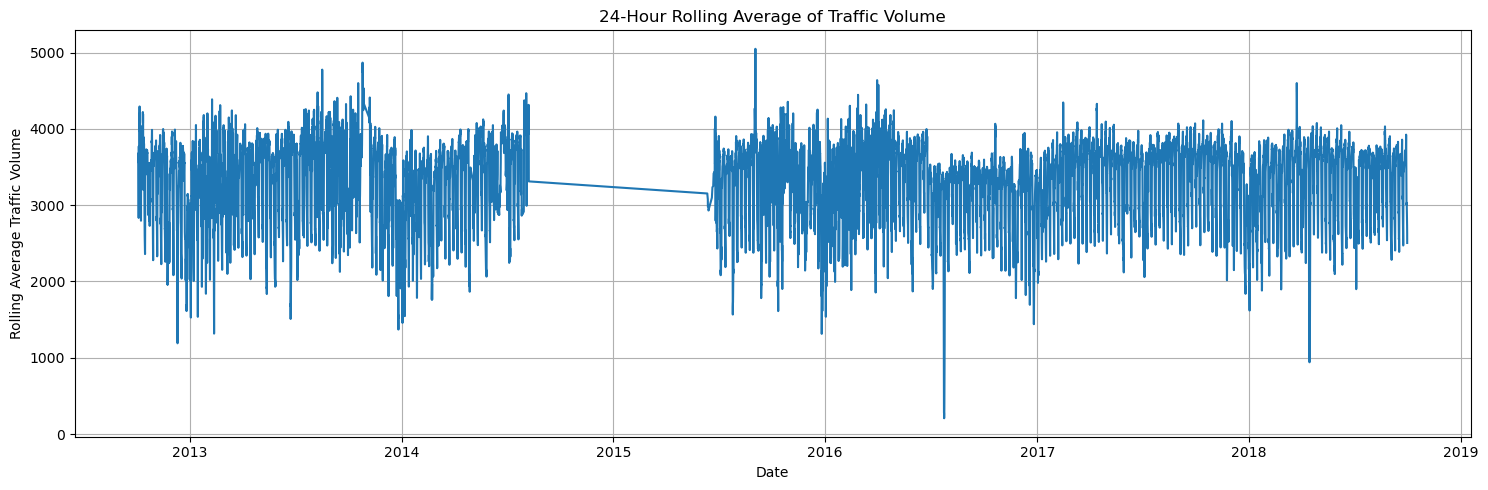

In [35]:
# Visualization 5: 24-hour rolling average
rolling_traffic = df.set_index("date_time")["traffic_volume"].rolling(24).mean()

plt.figure(figsize=(15, 5))
plt.plot(rolling_traffic)
plt.title("24-Hour Rolling Average of Traffic Volume")
plt.xlabel("Date")
plt.ylabel("Rolling Average Traffic Volume")
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
# Prepare the primary time-series variable
traffic = df[["traffic_volume"]].values

# Normalize traffic volume to the range 0–1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_traffic = scaler.fit_transform(traffic)

print("Scaled data shape:", scaled_traffic.shape)

Scaled data shape: (40575, 1)


In [37]:
# Chronological 80/20 train-test split
train_size = int(len(scaled_traffic) * 0.80)

train_data = scaled_traffic[:train_size]
test_data = scaled_traffic[train_size:]

print("Training observations:", len(train_data))
print("Testing observations :", len(test_data))

Training observations: 32460
Testing observations : 8115


In [38]:
# Create sequences: previous 24 hours -> next hour
sequence_length = 24

def create_sequences(data, sequence_length):
    X, y = [], []

    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, 0])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data, sequence_length)

# Include the final 24 training observations as context for the test set
combined_data = np.concatenate(
    [train_data[-sequence_length:], test_data]
)

X_test, y_test = create_sequences(combined_data, sequence_length)

# LSTM input shape: samples × time steps × features
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (32436, 24, 1)
X_test shape : (8115, 24, 1)
y_train shape: (32436,)
y_test shape : (8115,)


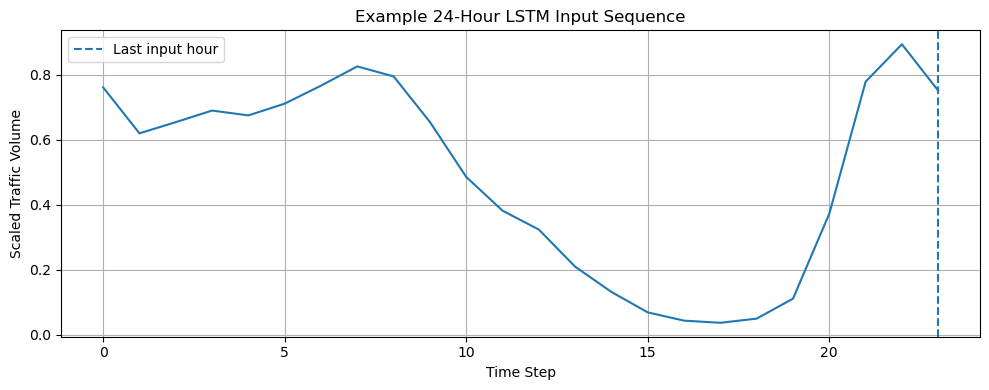

In [39]:
# Visualize one training sequence
plt.figure(figsize=(10, 4))
plt.plot(range(sequence_length), X_train[0, :, 0])
plt.axvline(sequence_length - 1, linestyle="--", label="Last input hour")
plt.title("Example 24-Hour LSTM Input Sequence")
plt.xlabel("Time Step")
plt.ylabel("Scaled Traffic Volume")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [40]:
# Build modified LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(sequence_length, 1)),
    Dropout(0.20),

    LSTM(32, return_sequences=False),
    Dropout(0.20),

    Dense(32, activation="relu"),
    Dropout(0.10),

    Dense(1)
], name="Traffic_LSTM_Forecaster")

model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

model.summary()

c:\Users\Shruti\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Traffic_LSTM_Forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,401 (118.75 KB)

 Trainable params: 30,401 (118.75 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Early stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.10,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
913/913 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - loss: 0.0340 - mae: 0.1365 - val_loss: 0.0050 - val_mae: 0.0524
Epoch 2/10
913/913 ━━━━━━━━━━━━━━━━━━━━ 30s 30ms/step - loss: 0.0118 - mae: 0.0772 - val_loss: 0.0038 - val_mae: 0.0449
Epoch 3/10
913/913 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - loss: 0.0094 - mae: 0.0677 - val_loss: 0.0033 - val_mae: 0.0421
Epoch 4/10
913/913 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - loss: 0.0083 - mae: 0.0632 - val_loss: 0.0037 - val_mae: 0.0451
Epoch 5/10
913/913 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - loss: 0.0077 - mae: 0.0607 - val_loss: 0.0029 - val_mae: 0.0401
Epoch 6/10
913/913 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - loss: 0.0073 - mae: 0.0592 - val_loss: 0.0024 - val_mae: 0.0366
Epoch 7/10
913/913 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - loss: 0.0071 - mae: 0.0581 - val_loss: 0.0023 - val_mae: 0.0346
Epoch 8/10
913/913 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - loss: 0.0069 - mae: 0.0572 - val_loss: 0.0036 - val_mae: 0.0444
Epoch 9/10
913/913 ━━━━━━━━━━━━━━━━━━━━ 

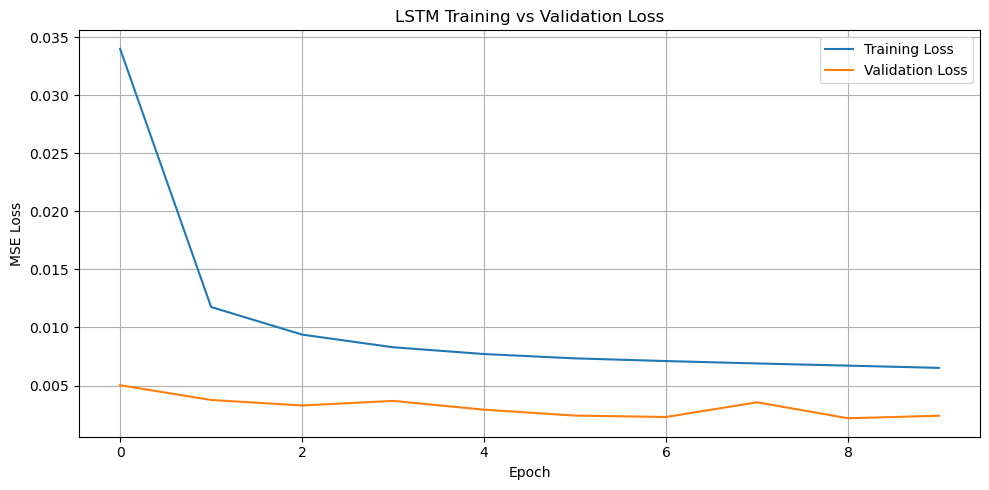

In [42]:
# Training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

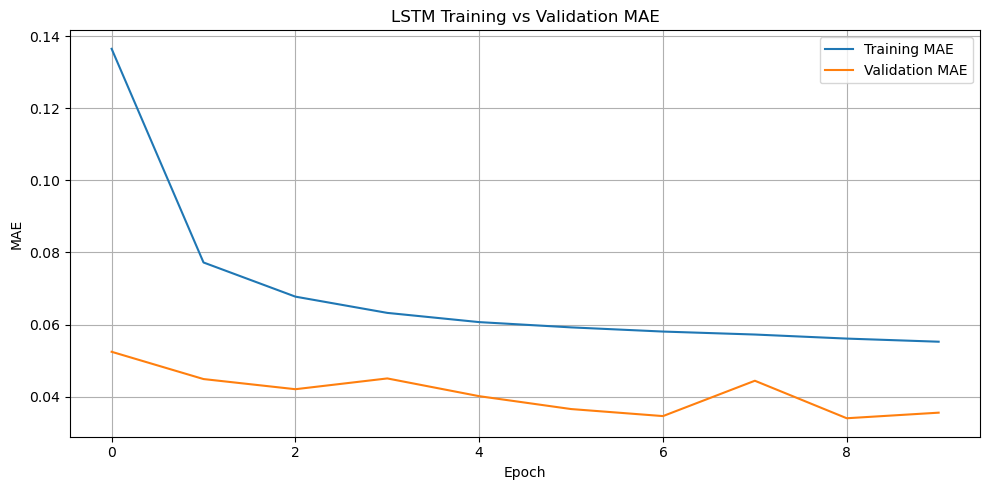

In [43]:
# Training and validation MAE
plt.figure(figsize=(10, 5))
plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.title("LSTM Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
# Generate test predictions
predictions = model.predict(X_test, verbose=0)

predicted_traffic = scaler.inverse_transform(predictions).flatten()
actual_traffic = scaler.inverse_transform(
    y_test.reshape(-1, 1)
).flatten()

print("Predictions generated:", len(predicted_traffic))

Predictions generated: 8115


In [45]:
# Evaluate the model
mae = mean_absolute_error(actual_traffic, predicted_traffic)

rmse = np.sqrt(
    mean_squared_error(actual_traffic, predicted_traffic)
)

non_zero = actual_traffic != 0

mape = np.mean(
    np.abs(
        (actual_traffic[non_zero] - predicted_traffic[non_zero])
        / actual_traffic[non_zero]
    )
) * 100

results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE"],
    "Value": [mae, rmse, mape]
})

print("LSTM MODEL PERFORMANCE")
print(f"MAE  : {mae:.2f} vehicles/hour")
print(f"RMSE : {rmse:.2f} vehicles/hour")
print(f"MAPE : {mape:.2f}%")

display(results)

LSTM MODEL PERFORMANCE
MAE  : 244.13 vehicles/hour
RMSE : 338.49 vehicles/hour
MAPE : 12.32%


,Metric,Value
0,MAE,244.132200
1,RMSE,338.492049
2,MAPE,12.321612


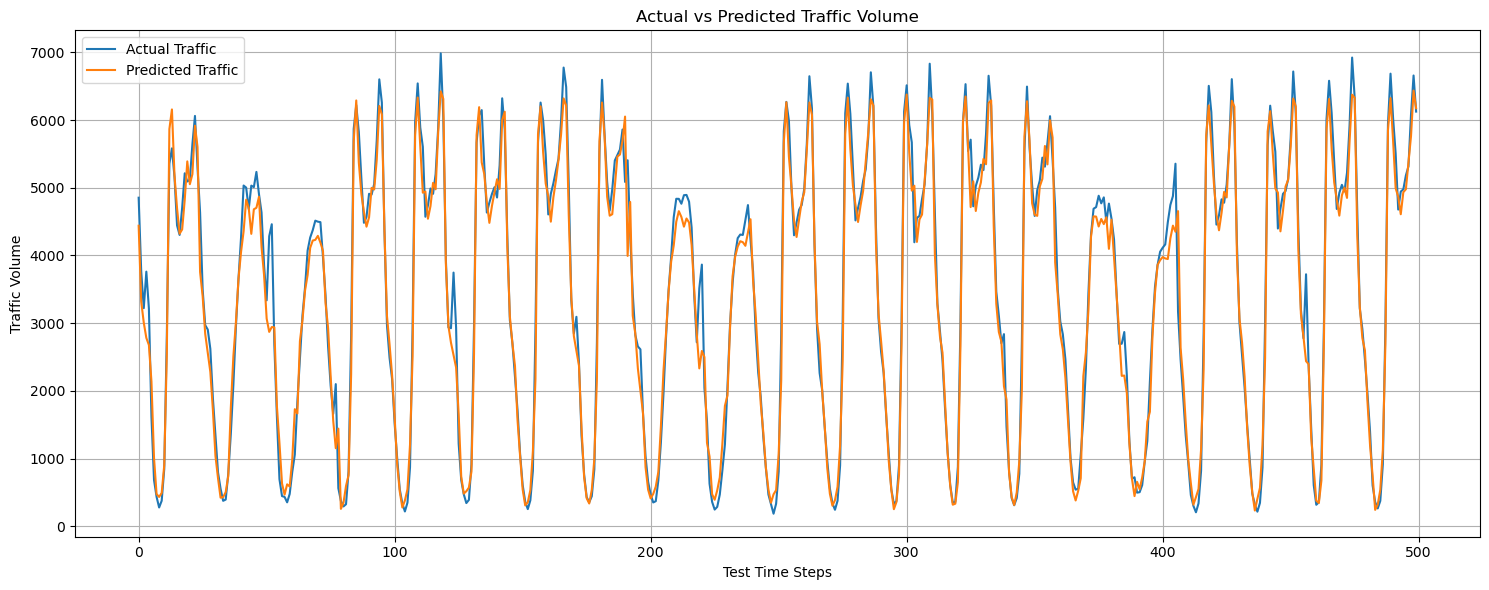

In [46]:
# Actual vs predicted traffic
plot_points = min(500, len(actual_traffic))

plt.figure(figsize=(15, 6))
plt.plot(actual_traffic[:plot_points], label="Actual Traffic")
plt.plot(predicted_traffic[:plot_points], label="Predicted Traffic")
plt.title("Actual vs Predicted Traffic Volume")
plt.xlabel("Test Time Steps")
plt.ylabel("Traffic Volume")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

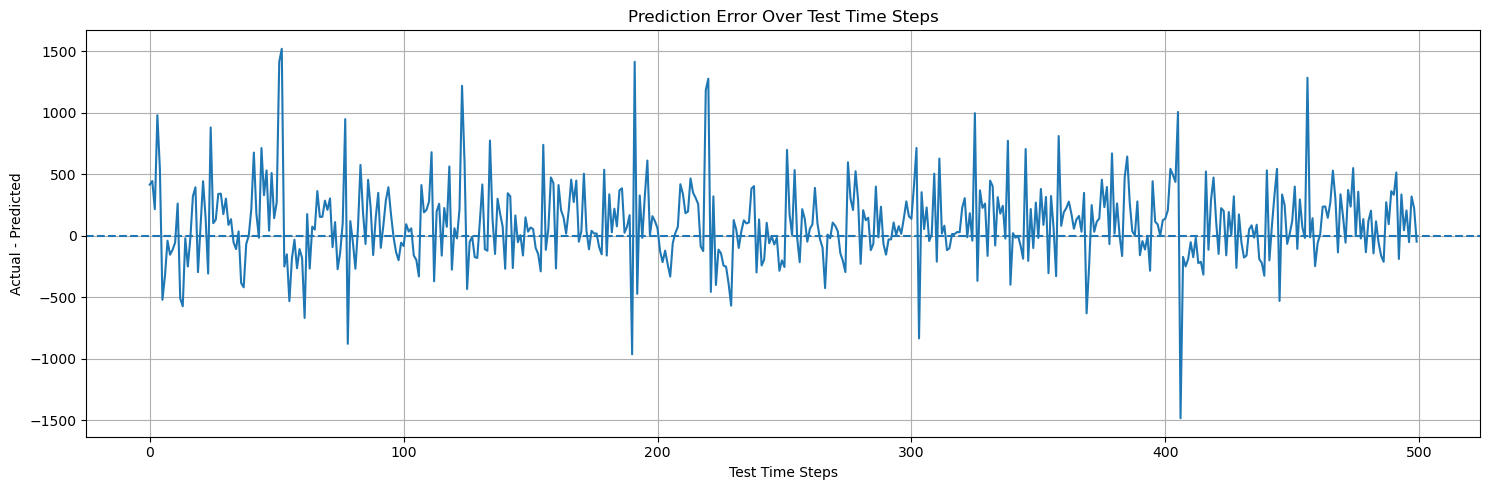

In [47]:
# Prediction error visualization
errors = actual_traffic[:plot_points] - predicted_traffic[:plot_points]

plt.figure(figsize=(15, 5))
plt.plot(errors)
plt.axhline(0, linestyle="--")
plt.title("Prediction Error Over Test Time Steps")
plt.xlabel("Test Time Steps")
plt.ylabel("Actual - Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

In [48]:
# Predict the next hour
last_24_hours = scaled_traffic[-sequence_length:]
last_24_hours = last_24_hours.reshape(1, sequence_length, 1)

next_hour_scaled = model.predict(last_24_hours, verbose=0)

next_hour_traffic = scaler.inverse_transform(
    next_hour_scaled
)[0][0]

print("=" * 45)
print("NEXT-HOUR FORECAST")
print("=" * 45)
print(
    f"Predicted traffic volume for the next hour: "
    f"{next_hour_traffic:.0f} vehicles"
)

NEXT-HOUR FORECAST
Predicted traffic volume for the next hour: 649 vehicles


In [49]:
# Save the trained model
MODEL_PATH = "lstm_traffic_forecaster.keras"
model.save(MODEL_PATH)

print(f"Model saved as: {MODEL_PATH}")

Model saved as: lstm_traffic_forecaster.keras
